# Vergleich der BiLSTM-Regressoren bei verschiedenen Inputlängen

Dieses Notebook vergleicht die Leistung der vier trainierten `BiLSTMRegressor`-Modelle (mit maximalen Sequenzlängen von **128, 256, 500 und 1000** Tokens).

Wir untersuchen:
1. **In-Domain Leistung:** MSE/MAE und Korrelation auf dem Validierungs-Split.
2. **Out-of-Domain (OOD) Generalisierung:** Leistung auf dem Lebenshilfe-Synthetik-Set.
3. **Kreuz-Evaluierung (Cross-Evaluation):** Wie verhält sich ein Modell, das auf kurzen Sequenzen trainiert wurde, wenn es lange Sequenzen sieht (und umgekehrt)?
4. **Monotonie-Erhaltung:** Welches Modell bildet die synthetischen Stufen (0.00 bis 1.00) am präzisesten und linearsten ab?

In [1]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


In [2]:
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr, spearmanr

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {device}")

# Pfade definieren
CORPUS_WITH_STEPS_PATH = "data/corpus/final_with_steps.json"
LH_WITH_STEPS_PATH = "data/lebenshilfe/lebenshilfe_dataset_with_steps.json"
VOCAB_SAVE_PATH = "data/vocabs/synthetic_vocab.json"

MODEL_PATHS = {
    128: "results/models/bilstm_synthetic_regression_len128.pt",
    256: "results/models/bilstm_synthetic_regression_len256.pt",
    500: "results/models/bilstm_synthetic_regression_len500.pt",
    1000: "results/models/bilstm_synthetic_regression_len1000.pt"
}

Nutze Device: cuda


## 1. Datensätze & Tokenisierung vorbereiten

In [3]:
# Vokabular laden
if not os.path.exists(VOCAB_SAVE_PATH):
    raise FileNotFoundError(f"Bitte trainiere zuerst mindestens ein Modell, um das Vokabular unter {VOCAB_SAVE_PATH} zu erstellen!")

with open(VOCAB_SAVE_PATH, "r", encoding="utf-8") as f:
    vocab = json.load(f)

nlp = spacy.blank("de")

def load_flattened_samples(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        articles = json.load(f)
        
    samples = []
    for art_idx, art in enumerate(articles):
        ls_text = art.get("ls_text", "").strip()
        as_text = art.get("as_text", "").strip()
        steps = art.get("intermediate_steps", {})
        
        if ls_text:
            samples.append({"text": ls_text, "target": 1.0, "article_id": art_idx, "stage": "1.00"})
        if as_text:
            samples.append({"text": as_text, "target": 0.0, "article_id": art_idx, "stage": "0.00"})
            
        for step_str, step_text in steps.items():
            try:
                target_val = float(step_str)
                if step_text and step_text.strip():
                    samples.append({
                        "text": step_text.strip(),
                        "target": 1.0 - target_val,
                        "article_id": art_idx,
                        "stage": f"{1.0 - target_val:.2f}"
                    })
            except ValueError:
                continue
                
    return samples

raw_samples = load_flattened_samples(CORPUS_WITH_STEPS_PATH)
lh_samples = load_flattened_samples(LH_WITH_STEPS_PATH)

class SyntheticStepDataset(Dataset):
    def __init__(self, samples, vocab, nlp_spacy, max_len):
        self.samples = samples
        self.vocab = vocab
        self.nlp = nlp_spacy
        self.max_len = max_len
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        item = self.samples[idx]
        doc = self.nlp(item["text"])
        tokens = [t.text.lower() for t in doc if not t.is_space][:self.max_len]
        
        token_ids = [self.vocab.get(t, self.vocab["<UNK>"]) for t in tokens]
        if not token_ids:
            token_ids = [self.vocab["<PAD>"]]
            
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(item["target"], dtype=torch.float32), item["stage"]

def pad_collate_fn(batch):
    sequences, targets, stages = zip(*batch)
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0)
    targets = torch.tensor(targets, dtype=torch.float32)
    return padded_seqs, targets, stages

# Split auf dieselbe Weise reproduzieren (Seed 42)
import random
unique_art_ids = list(set(s["article_id"] for s in raw_samples))
random.seed(42)
random.shuffle(unique_art_ids)
split_idx = int(0.8 * len(unique_art_ids))
val_art_ids = set(unique_art_ids[split_idx:])
val_samples = [s for s in raw_samples if s["article_id"] in val_art_ids]

print(f"Anzahl Val-Samples (In-Domain): {len(val_samples)}")
print(f"Anzahl Lebenshilfe-Samples (OOD): {len(lh_samples)}")

Anzahl Val-Samples (In-Domain): 1480
Anzahl Lebenshilfe-Samples (OOD): 245


## 2. Modellarchitektur definieren

In [4]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out).squeeze(-1)

## 3. Evaluierungs-Funktion definieren

In [5]:
def evaluate_model(model_path, dataset_samples, max_len):
    if not os.path.exists(model_path):
        print(f"Warning: Modelldatei nicht gefunden unter {model_path}")
        return None
        
    model = BiLSTMRegressor(vocab_size=len(vocab)).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    ds = SyntheticStepDataset(dataset_samples, vocab, nlp, max_len=max_len)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=pad_collate_fn)
    
    all_preds = []
    all_targets = []
    all_stages = []
    
    with torch.no_grad():
        for x_batch, y_batch, stages in loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())
            all_stages.extend(stages)
            
    preds = np.array(all_preds)
    targets = np.array(all_targets)
    
    mse = np.mean((preds - targets) ** 2)
    mae = np.mean(np.abs(preds - targets))
    r, _ = pearsonr(preds, targets)
    rho, _ = spearmanr(preds, targets)
    
    return {
        "mse": mse,
        "mae": mae,
        "pearson_r": r,
        "spearman_rho": rho,
        "predictions": preds,
        "targets": targets,
        "stages": all_stages
    }

## 4. Evaluierung ausführen

In [6]:
results_val = {}
results_lh = {}

for length, path in MODEL_PATHS.items():
    print(f"Evaluiere Modell mit Sequenzlänge {length}...")
    
    # Evaluierung auf dem Validation-Set (mit der jeweiligen Trainingslänge)
    res_v = evaluate_model(path, val_samples, max_len=length)
    if res_v:
        results_val[length] = res_v
        
    # Evaluierung auf Lebenshilfe (OOD)
    res_lh = evaluate_model(path, lh_samples, max_len=length)
    if res_lh:
        results_lh[length] = res_lh

Evaluiere Modell mit Sequenzlänge 128...
Evaluiere Modell mit Sequenzlänge 256...
Evaluiere Modell mit Sequenzlänge 500...
Evaluiere Modell mit Sequenzlänge 1000...


## 5. Vergleich der Performance-Metriken

In [7]:
# DataFrame für Validierungsdaten erstellen
val_data = []
for len_key, res in results_val.items():
    val_data.append({
        "Modell": f"Len-{len_key}",
        "Val MSE": res["mse"],
        "Val MAE": res["mae"],
        "Val Pearson r": res["pearson_r"],
        "Val Spearman rho": res["spearman_rho"]
    })

# DataFrame für Lebenshilfe erstellen
lh_data = []
for len_key, res in results_lh.items():
    lh_data.append({
        "Modell": f"Len-{len_key}",
        "LH MSE": res["mse"],
        "LH MAE": res["mae"],
        "LH Pearson r": res["pearson_r"],
        "LH Spearman rho": res["spearman_rho"]
    })

df_val = pd.DataFrame(val_data)
df_lh = pd.DataFrame(lh_data)

df_comparison = pd.merge(df_val, df_lh, on="Modell") if not df_val.empty and not df_lh.empty else pd.DataFrame()
df_comparison.round(4)

,Modell,Val MSE,Val MAE,Val Pearson r,Val Spearman rho,LH MSE,LH MAE,LH Pearson r,LH Spearman rho
0,Len-128,0.0319,0.1178,0.8701,0.8664,0.0821,0.1919,0.7253,0.6945
1,Len-256,0.0325,0.1330,0.8617,0.8572,0.0850,0.2136,0.7203,0.6862
2,Len-500,0.0355,0.1274,0.8623,0.8693,0.0959,0.2128,0.7150,0.6941
3,Len-1000,0.0328,0.1335,0.8593,0.8497,0.0903,0.2241,0.6597,0.6469


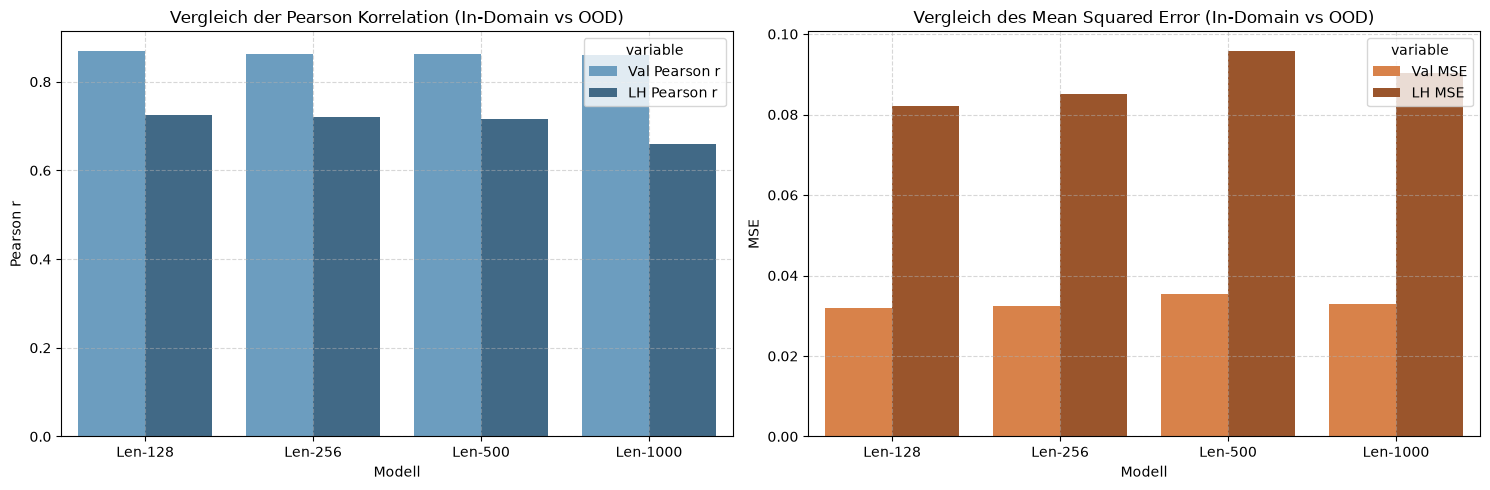

In [8]:
if not df_comparison.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Korrelationsvergleich
    df_melted_corr = pd.melt(df_comparison, id_vars=['Modell'], value_vars=['Val Pearson r', 'LH Pearson r'])
    sns.barplot(data=df_melted_corr, x='Modell', y='value', hue='variable', ax=axes[0], palette='Blues_d')
    axes[0].set_title("Vergleich der Pearson Korrelation (In-Domain vs OOD)")
    axes[0].set_ylabel("Pearson r")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    
    # MSE Vergleich
    df_melted_mse = pd.melt(df_comparison, id_vars=['Modell'], value_vars=['Val MSE', 'LH MSE'])
    sns.barplot(data=df_melted_mse, x='Modell', y='value', hue='variable', ax=axes[1], palette='Oranges_d')
    axes[1].set_title("Vergleich des Mean Squared Error (In-Domain vs OOD)")
    axes[1].set_ylabel("MSE")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## 6. Kreuz-Evaluierung (Cross-Evaluation)

Hier untersuchen wir, was passiert, wenn wir die Modelle mit einer anderen Sequenzlänge als der Trainingslänge füttern. 
Dies zeigt auf, ob längere Kontexte beim Testen von kurzen Modellen genutzt werden können oder ob längere Modelle auf kurzen Texten an Genauigkeit verlieren.

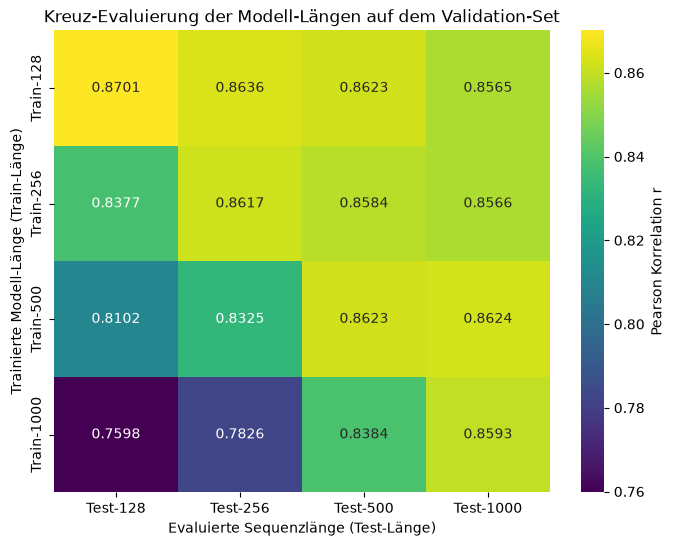

In [9]:
cross_matrix = np.zeros((4, 4)) # Zeilen: Train-Länge, Spalten: Test-Länge
lengths_list = [128, 256, 500, 1000]

for i, train_len in enumerate(lengths_list):
    model_path = MODEL_PATHS[train_len]
    for j, test_len in enumerate(lengths_list):
        res = evaluate_model(model_path, val_samples, max_len=test_len)
        if res:
            cross_matrix[i, j] = res["pearson_r"]
        else:
            cross_matrix[i, j] = np.nan

df_cross = pd.DataFrame(cross_matrix, index=[f"Train-{l}" for l in lengths_list], columns=[f"Test-{l}" for l in lengths_list])

plt.figure(figsize=(8, 6))
sns.heatmap(df_cross, annot=True, cmap="viridis", fmt=".4f", cbar_kws={'label': 'Pearson Korrelation r'})
plt.title("Kreuz-Evaluierung der Modell-Längen auf dem Validation-Set")
plt.xlabel("Evaluierte Sequenzlänge (Test-Länge)")
plt.ylabel("Trainierte Modell-Länge (Train-Länge)")
plt.show()

## 7. Monotonie-Verlauf über die Stufen

Ein gutes Regressionsmodell sollte die Stufen (0.00 bis 1.00) möglichst gleichmäßig und linear abbilden. Wir visualisieren den mittleren vorhergesagten Score je Zielstufe für alle Modelle im direkten Vergleich.

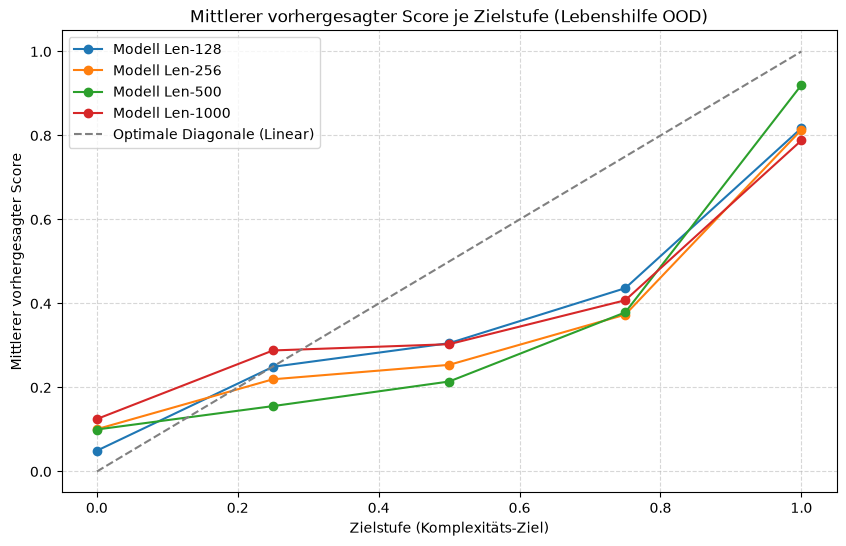

In [10]:
plt.figure(figsize=(10, 6))

for length, res in results_lh.items():
    df_temp = pd.DataFrame({
        "Zielstufe": res["stages"],
        "Vorhergesagter Score": res["predictions"]
    })
    # Durchschnittlichen Score je Stufe berechnen
    df_mean = df_temp.groupby("Zielstufe")["Vorhergesagter Score"].mean().reset_index()
    df_mean["Zielstufe"] = df_mean["Zielstufe"].astype(float)
    df_mean = df_mean.sort_values("Zielstufe")
    
    plt.plot(df_mean["Zielstufe"], df_mean["Vorhergesagter Score"], marker="o", label=f"Modell Len-{length}")

# Optimale diagonale Referenzlinie
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Optimale Diagonale (Linear)")

plt.title("Mittlerer vorhergesagter Score je Zielstufe (Lebenshilfe OOD)")
plt.xlabel("Zielstufe (Komplexitäts-Ziel)")
plt.ylabel("Mittlerer vorhergesagter Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 8. Wissenschaftliches Fazit

### Leitfragen zur Analyse:

1. **Gibt es ein Optimum der Inputlänge?**
   * Verbessert sich die Vorhersagekraft (Pearson $r$) stetig von 128 bis 1000, oder flacht die Kurve ab (Sättigungseffekt)?
   * Kurze Texte weisen oft weniger Rauschen auf. Könnte ein zu langer Kontext (`Len-1000`) zu Overfitting auf irrelevante Füllwörter führen?

2. **Robustheit & Generalisierung (OOD-Transfer):**
   * Welches Modell schneidet auf dem Lebenshilfe-Datensatz am besten ab?
   * Führt eine längere Sequenzlänge zu einer stabileren Bewertung auf ungesehenen Textstrukturen?

3. **Interpretation der Kreuz-Evaluierung (Cross-Evaluation):**
   * Wenn das `Len-128`-Modell auf `Test-1000` angewendet wird, nutzt es die zusätzlichen Tokens, oder ignoriert das Modell diese (da es nie gelernt hat, längere Sequenzen zu betrachten)?
   * Wenn ein `Len-1000`-Modell auf `Test-128` getestet wird, bricht die Performance ein? Dies deutet darauf hin, ob das Modell auf das Ende der Sequenz (durch den BiLSTM-Backward-Pass) angewiesen ist, um präzise Vorhersagen zu treffen.